In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
df = pd.read_csv("train.csv")
print(df.shape)
df.head()

(42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


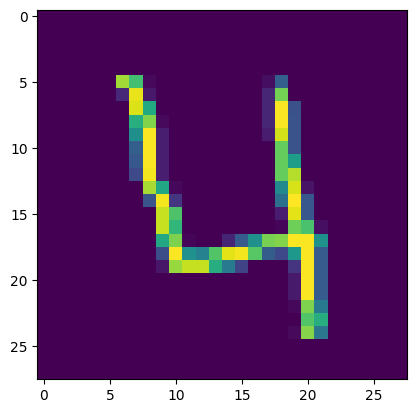

In [3]:
import matplotlib.pyplot as plt
# print(df.iloc[3, 1:])
# print(df.iloc[3, 1:].values)
# print(df.iloc[3, 1:].values.reshape(28,28))
plt.imshow(df.iloc[3, 1:].values.reshape(28,28))

In [4]:
from sklearn.model_selection import train_test_split

# Define features and target
def get_X_Y(df):
    X = df.drop(columns=["label"])
    Y = df["label"]
    return X, Y


X, Y = get_X_Y(df)
# Split data into train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=5
)

print(X_train.shape)

(33600, 784)



amount of variance explained by each principal component: 
 [3.35479134e+05 2.44878341e+05 2.11473487e+05 1.84484277e+05
 1.68552351e+05 1.47762417e+05 1.12919912e+05 9.91435424e+04
 9.47610298e+04 8.04496339e+04 7.21351378e+04 7.03486006e+04
 5.88257931e+04 5.83631326e+04 5.42893877e+04 5.10314019e+04
 4.50660857e+04 4.40814776e+04 4.06215352e+04 3.95365790e+04
 3.66529013e+04 3.47471581e+04 3.31053185e+04 3.12252393e+04
 3.03924218e+04 2.87567801e+04 2.79305761e+04 2.67742141e+04
 2.54407327e+04 2.35878683e+04 2.25569593e+04 2.19613785e+04
 2.05318105e+04 2.01371549e+04 1.93388378e+04 1.86667385e+04
 1.74892638e+04 1.67044829e+04 1.63205009e+04 1.60421682e+04
 1.55239840e+04 1.51519341e+04 1.43878531e+04 1.37354438e+04
 1.32490610e+04 1.29403603e+04 1.24407165e+04 1.20042445e+04
 1.15292329e+04 1.10075857e+04 1.08848786e+04 1.05716002e+04
 1.00834108e+04 9.85903313e+03 9.62983523e+03 9.27792497e+03
 9.13981473e+03 8.81937555e+03 8.71733272e+03 8.45126588e+03
 8.27302403e+03 8.165033

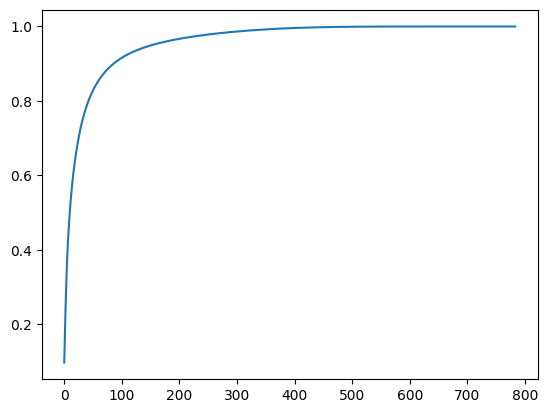

In [5]:
from sklearn.decomposition import PCA

# calculating optimal no. of principal components

n_comp = None
pca = PCA(n_components=n_comp)
X_train_trf = pca.fit_transform(X_train)

print("\namount of variance explained by each principal component: \n", pca.explained_variance_)
# This means: [4.22824171 0.24267075 0.0782095  0.02383509]
# PC1 explains variance of 4.22
# PC2 explains 0.24
# PC3 explains 0.078
# PC4 explains 0.024

print("\nn_components: Number of principal components you asked PCA to keep,\nn_features: Number of original features in your dataset:\n (n_components, n_features):", pca.components_.shape)

print("\n The proportion (percentage) of total variance explained by each component:\n", pca.explained_variance_ratio_)
# This means: [0.92461872 0.05306648 0.01710261 0.00521218]
# PC1 explains ~92.5% of the variance
# PC2 explains ~5.3%
# PC3 explains ~1.7%
# PC4 explains ~0.5%

cumsum_arr = np.cumsum(pca.explained_variance_ratio_)
print("\ncumulative explained variance — i.e., how much total variance is explained up to each principal component.\nShows the total variance explained as you add more components\n", cumsum_arr)
# This means: [0.8, 0.9, 0.97, 1.0]
# PC1 explains 80%
# PC1 + PC2 explains 90%
# PC1 + PC2 + PC3 explains 97%
# All components explain 100% (or close to it due to rounding)

print("\nplots a curve showing how the cumulative explained variance increases as more principal components are included.")
plt.plot(cumsum_arr)

def first_90_index_binary(lst):
    low, high = 0, len(lst) - 1
    result = -1
    while low <= high:
        mid = (low + high) // 2
        if lst[mid] >= 0.90:
            result = mid
            high = mid - 1  # Look for earlier occurrence
        else:
            low = mid + 1
    return result

optimal_pc = first_90_index_binary(cumsum_arr)
print("optimal no. of principal components required: ", optimal_pc)

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import (StandardScaler)

n_comp = optimal_pc
pca = PCA(n_components=n_comp)

numerical_features = X_train.columns
numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ('pca', pca)
    ]
)

In [7]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
    ]
)
# Define the pipeline
pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])

# Fit the pipeline on the training data
pipeline.fit(X_train, Y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('pca',
                                                                   PCA(n_components=86))]),
                                                  Index(['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=784))])),
                ('model', KNeighborsClassifier())])

In [8]:
# Evaluate the model
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(Y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9541666666666667


In [9]:

def generate_submission(test_file):
    # Read the CSV file into a DataFrame
    df = pd.read_csv(test_file)
    df.insert(0, 'ImageId', range(1, len(df) + 1))
    filtered_df = df
    print(filtered_df.shape)
    predictions = pipeline.predict(filtered_df)
    filtered_df["Label"] = predictions
    # Save the results to a new CSV file
    submission_df = filtered_df[["ImageId", "Label"]]
    submission_df.to_csv("submission.csv", index=False)
    print("Submission file saved as 'submission.csv'")


# Generate the submission
test_file = "test.csv"
generate_submission(test_file)

(28000, 785)
Submission file saved as 'submission.csv'


In [10]:
# 2d graph of 3 principal components
n_comp = 2
pca = PCA(n_components=n_comp)
X_train_trf = pca.fit_transform(X_train)
# plotly used for dynamic visualisation when hovering over the graph
# x is PC-1 and y is PC-2
import plotly.express as px
fig = px.scatter(x = X_train_trf[:,0], y = X_train_trf[:,1], color = Y_train.astype(str), color_discrete_sequence = px.colors.qualitative.G10)
fig.show()

In [11]:
# 3d graph of 3 principal components
# x is PC-1 and y is PC-2 & z = PC-3
n_comp = 3
pca = PCA(n_components=n_comp)
X_train_trf = pca.fit_transform(X_train)
fig = px.scatter_3d(x = X_train_trf[:,0], y = X_train_trf[:,1], z = X_train_trf[:,2], color = Y_train.astype(str), color_discrete_sequence = px.colors.qualitative.G10)
fig.show()